In [2]:
##Import Libraries
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [3]:
#importing the rawdata
df = pd.read_excel(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\raw_students.xlsx")
print(df.describe())



               Age  Study_Hours  Attendance  Breakfast_Calories  Sleep_Hours  \
count  1003.000000  1003.000000  998.000000         1003.000000  1000.000000   
mean     21.794616     4.458325   80.914830          532.631107     6.544000   
std       7.575415     2.444305   12.435662          213.302699     1.428063   
min      18.000000     1.000000  -20.000000          250.000000     4.000000   
25%      20.000000     2.800000   70.000000          389.000000     5.300000   
50%      22.000000     4.400000   81.000000          529.000000     6.500000   
75%      24.000000     6.000000   92.000000          668.000000     7.800000   
max     250.000000    50.000000  150.000000         5000.000000     9.000000   

        Math_Score  
count  1003.000000  
mean     70.248255  
std      17.261728  
min      40.000000  
25%      55.000000  
50%      70.000000  
75%      85.000000  
max     100.000000  


In [4]:
print("Original Shape:", df.shape)

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)
print(df)

output_path = r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\cleaned_students.xlsx"
df.to_excel(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")

Original Shape: (1003, 8)
Missing Values:
Student_ID            0
Age                   0
Gender                0
Study_Hours           0
Attendance            5
Breakfast_Calories    0
Sleep_Hours           3
Math_Score            0
dtype: int64
Duplicate Rows: 3
    Student_ID  Age Gender  Study_Hours  Attendance  Breakfast_Calories  \
0        S0001   19      M          6.2        75.0                 478   
1        S0002   19      F          1.2        65.0                 473   
2        S0003   18      M          6.0        94.0                 679   
3        S0004   22      M          6.3        70.0                 682   
4        S0005   21      F          1.7        84.0                 349   
..         ...  ...    ...          ...         ...                 ...   
987      S0996   24      F          4.2        62.0                 431   
988      S0997   22      M          4.4        68.0                 569   
989      S0998   19      F          5.6        94.0         

In [5]:
#importing the cleaneddata

df = pd.read_excel(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\cleaned_students.xlsx")
print(df.describe())

              Age  Study_Hours  Attendance  Breakfast_Calories  Sleep_Hours  \
count  992.000000   992.000000  992.000000          992.000000   992.000000   
mean    21.805444     4.457964   80.884073          532.650202     6.544052   
std      7.612954     2.446711   12.438655          214.016776     1.429791   
min     18.000000     1.000000  -20.000000          250.000000     4.000000   
25%     20.000000     2.800000   70.000000          389.000000     5.300000   
50%     22.000000     4.400000   81.000000          529.500000     6.500000   
75%     24.000000     6.000000   92.000000          668.000000     7.800000   
max    250.000000    50.000000  150.000000         5000.000000     9.000000   

       Math_Score  
count   992.00000  
mean     70.21371  
std      17.28291  
min      40.00000  
25%      55.00000  
50%      70.00000  
75%      85.00000  
max     100.00000  


In [6]:
#Outlier Detection and Removal(Math_Score)
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Math_Score'] >= lower_bound) & (df['Math_Score'] <= upper_bound)]
print("Shape after Outlier Removal:", df.shape)
print(df.describe())
print(df)


#Outlier Detection and Removal(Study_Hours)
Q1 = df['Study_Hours'].quantile(0.25)
Q3 = df['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Study_Hours'] >= lower_bound) & (df['Study_Hours'] <= upper_bound)]
print("Shape after Outlier Removal:", df.shape)
print(df)


#Outlier Detection and Removal(Breakfast_Calories)
Q1 = df['Breakfast_Calories'].quantile(0.25)
Q3 = df['Breakfast_Calories'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Breakfast_Calories'] >= lower_bound) & (df['Breakfast_Calories'] <= upper_bound)]
print("Shape after Outlier Removal:", df.shape)
print(df.describe())
print(df)

#Outlier Detection and Removal(Attendance)
Q1 = df['Attendance'].quantile(0.25)
Q3 = df['Attendance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Attendance'] >= lower_bound) & (df['Attendance'] <= upper_bound)]
print("Shape after Outlier Removal:", df.shape)
print(df.describe())
print(df)


df.to_excel(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\outlier_report.xlsx", index=False)
print("Saved cleaned data to outlier_report.xlsx")

Shape after Outlier Removal: (992, 8)
              Age  Study_Hours  Attendance  Breakfast_Calories  Sleep_Hours  \
count  992.000000   992.000000  992.000000          992.000000   992.000000   
mean    21.805444     4.457964   80.884073          532.650202     6.544052   
std      7.612954     2.446711   12.438655          214.016776     1.429791   
min     18.000000     1.000000  -20.000000          250.000000     4.000000   
25%     20.000000     2.800000   70.000000          389.000000     5.300000   
50%     22.000000     4.400000   81.000000          529.500000     6.500000   
75%     24.000000     6.000000   92.000000          668.000000     7.800000   
max    250.000000    50.000000  150.000000         5000.000000     9.000000   

       Math_Score  
count   992.00000  
mean     70.21371  
std      17.28291  
min      40.00000  
25%      55.00000  
50%      70.00000  
75%      85.00000  
max     100.00000  
    Student_ID  Age Gender  Study_Hours  Attendance  Breakfast_Calorie

In [7]:
##importing the outlier_report
df = pd.read_excel(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\outlier_report.xlsx")
print(df.describe())
print(df.info())

              Age  Study_Hours  Attendance  Breakfast_Calories  Sleep_Hours  \
count  988.000000   988.000000  988.000000          988.000000   988.000000   
mean    21.798583     4.410931   80.928138          528.495951     6.546255   
std      7.625805     1.976109   11.827016          160.215227     1.432173   
min     18.000000     1.000000   60.000000          250.000000     4.000000   
25%     20.000000     2.800000   70.000000          389.000000     5.300000   
50%     22.000000     4.400000   81.000000          530.000000     6.550000   
75%     24.000000     6.000000   92.000000          668.000000     7.800000   
max    250.000000     8.000000  100.000000          800.000000     9.000000   

       Math_Score  
count  988.000000  
mean    70.231781  
std     17.305349  
min     40.000000  
25%     55.000000  
50%     70.000000  
75%     85.000000  
max    100.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 8 columns):
 #  

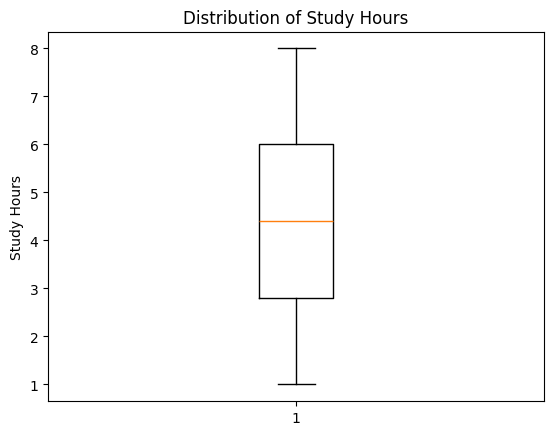

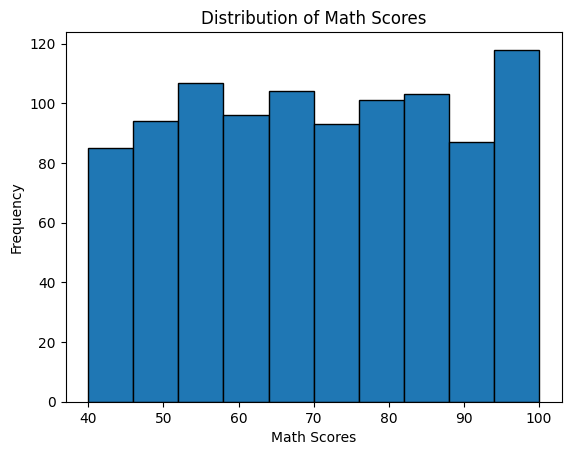

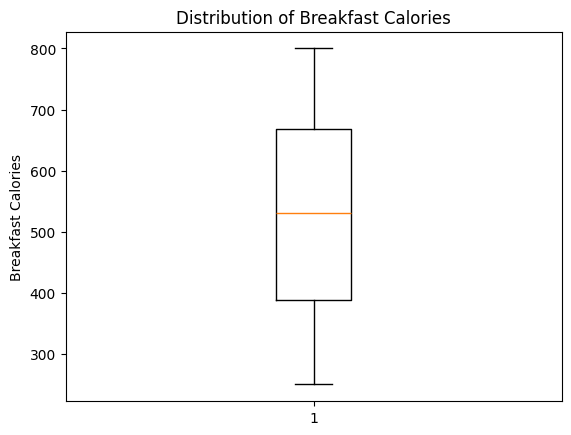

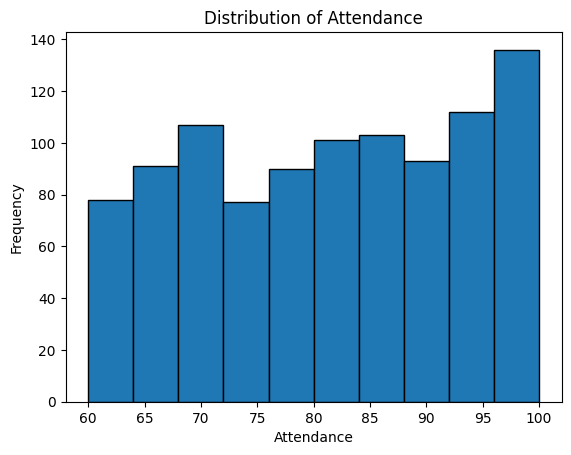

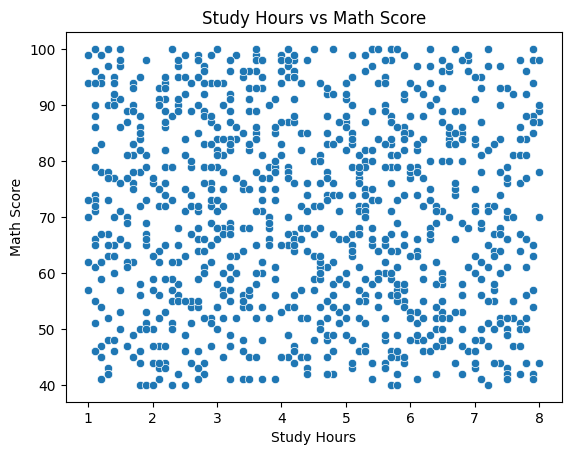

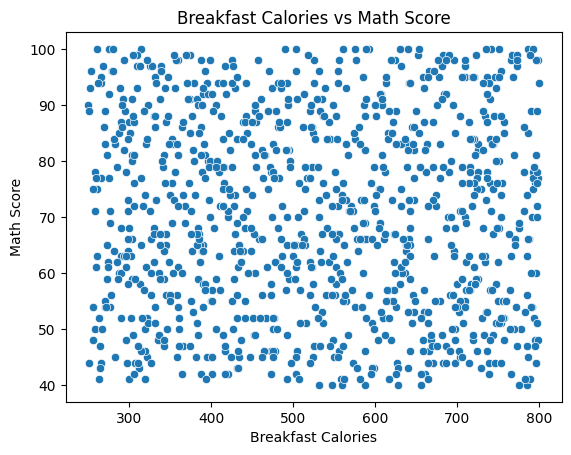

In [8]:
##Visualization of Study Hours
plt.boxplot(df['Study_Hours'])
plt.title('Distribution of Study Hours')
plt.ylabel('Study Hours')
plt.show()
##Visualization of Math Score
plt.hist(df['Math_Score'], bins=10, edgecolor='black')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Scores')
plt.ylabel('Frequency')
plt.show()
##Visualization of Breakfast Calories
plt.boxplot(df['Breakfast_Calories'])   
plt.title('Distribution of Breakfast Calories')
plt.ylabel('Breakfast Calories')    
plt.show()
##Visualization of Attendance
plt.hist(df['Attendance'], bins=10, edgecolor='black')
plt.title('Distribution of Attendance')
plt.xlabel('Attendance')    
plt.ylabel('Frequency')
plt.show()
##Visualization of study_hours vs math_score
sns.scatterplot(x='Study_Hours', y='Math_Score', data=df)       
plt.title('Study Hours vs Math Score')
plt.xlabel('Study Hours')   
plt.ylabel('Math Score')
plt.show()
##visualization of breakfast_calories vs math_score
sns.scatterplot(x='Breakfast_Calories', y='Math_Score', data=df)        
plt.title('Breakfast Calories vs Math Score')
plt.xlabel('Breakfast Calories')    
plt.ylabel('Math Score')
plt.show()

In [9]:
##Normalization of Study Hours
scaler = MinMaxScaler()
df['Study_Hours_Normalized'] = scaler.fit_transform(df[['Study_Hours']])
print(df[['Study_Hours', 'Study_Hours_Normalized']].head())
##Standardization of Math Scores
scaler = StandardScaler()
df['Math_Score_Standardized'] = scaler.fit_transform(df[['Math_Score']])
print(df[['Math_Score', 'Math_Score_Standardized']].head())
##Normalization of Breakfast Calories
scaler = MinMaxScaler()
df['Breakfast_Calories_Normalized'] = scaler.fit_transform(df[['Breakfast_Calories']])
print(df[['Breakfast_Calories', 'Breakfast_Calories_Normalized']].head())
##Standardization of Attendance
scaler = StandardScaler()
df['Attendance_Standardized'] = scaler.fit_transform(df[['Attendance']])
print(df[['Attendance', 'Attendance_Standardized']].head())
##Standardization of Study Hours
scaler = StandardScaler()
df['Study_Hours_Standardized'] = scaler.fit_transform(df[['Study_Hours']])
print(df[['Study_Hours', 'Study_Hours_Standardized']].head())   
##log transformation of Breakfast Calories
df['Breakfast_Calories_Log'] = np.log(df['Breakfast_Calories'])
print(df[['Breakfast_Calories', 'Breakfast_Calories_Log']].head())


   Study_Hours  Study_Hours_Normalized
0          6.2                0.742857
1          1.2                0.028571
2          6.0                0.714286
3          6.3                0.757143
4          1.7                0.100000
   Math_Score  Math_Score_Standardized
0          46                -1.400957
1          78                 0.449119
2          77                 0.391304
3          49                -1.227513
4          62                -0.475919
   Breakfast_Calories  Breakfast_Calories_Normalized
0                 478                       0.414545
1                 473                       0.405455
2                 679                       0.780000
3                 682                       0.785455
4                 349                       0.180000
   Attendance  Attendance_Standardized
0          75                -0.501491
1          65                -1.347441
2          94                 1.105814
3          70                -0.924466
4          84      

In [10]:
##Binning(Math_Score)
bins=[0,40,60,80,100]
labels=['Fail','Pass','Good','Excellent']
df['Math_Score_Binned'] = pd.cut(df['Math_Score'], bins=bins, labels=labels)
print(df[['Math_Score', 'Math_Score_Binned']].head())

numerical_cols = [
    'Age',
    'Study_Hours',
    'Attendance',
    'Breakfast_Calories',
    'Sleep_Hours',
    'Math_Score'
]

group_bins = df.groupby(
    'Math_Score_Binned'
)[numerical_cols].mean()

print(group_bins)


   Math_Score Math_Score_Binned
0          46              Pass
1          78              Good
2          77              Good
3          49              Pass
4          62              Good
                         Age  Study_Hours  Attendance  Breakfast_Calories  \
Math_Score_Binned                                                           
Fail               23.375000     3.650000   81.625000          633.875000   
Pass               22.230769     4.595385   80.606154          536.916923   
Good               21.513595     4.280060   81.604230          528.516616   
Excellent          21.617284     4.378395   80.543210          517.425926   

                   Sleep_Hours  Math_Score  
Math_Score_Binned                           
Fail                  7.087500   40.000000  
Pass                  6.527385   50.701538  
Good                  6.575227   70.404834  
Excellent             6.522222   90.391975  


C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_23516\1347059095.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_bins = df.groupby(


In [11]:
##polynomial feature creation for Study Hours
df['Study_Hours_Squared'] = df['Study_Hours'] ** 2
print(df[['Study_Hours', 'Study_Hours_Squared']].head())
##polynomial feature creation for Breakfast Calories
df['Breakfast_Calories_Squared'] = df['Breakfast_Calories'] ** 2
print(df[['Breakfast_Calories', 'Breakfast_Calories_Squared']].head())
##polynomial feature creation for Attendance
df['Attendance_Squared'] = df['Attendance'] ** 2
print(df[['Attendance', 'Attendance_Squared']].head())
##polynomial feature creation for Sleep Hours
df['Sleep_Hours_Squared'] = df['Sleep_Hours'] ** 2
print(df[['Sleep_Hours', 'Sleep_Hours_Squared']].head())
##polynomial feature creation for math score
df['Math_Score_Squared'] = df['Math_Score'] ** 2
print(df[['Math_Score', 'Math_Score_Squared']].head())

   Study_Hours  Study_Hours_Squared
0          6.2                38.44
1          1.2                 1.44
2          6.0                36.00
3          6.3                39.69
4          1.7                 2.89
   Breakfast_Calories  Breakfast_Calories_Squared
0                 478                      228484
1                 473                      223729
2                 679                      461041
3                 682                      465124
4                 349                      121801
   Attendance  Attendance_Squared
0          75                5625
1          65                4225
2          94                8836
3          70                4900
4          84                7056
   Sleep_Hours  Sleep_Hours_Squared
0          4.7                22.09
1          5.2                27.04
2          5.1                26.01
3          5.7                32.49
4          5.8                33.64
   Math_Score  Math_Score_Squared
0          46                2

In [12]:
# Get all numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

df_normalized = df.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df_normalized[numerical_cols].head())
print(df_normalized[numerical_cols].describe())

        Age  Study_Hours  Attendance  Breakfast_Calories  Sleep_Hours  \
0 -0.367174     0.905808   -0.501491           -0.315335    -1.289781   
1 -0.367174    -1.625698   -1.347441           -0.346559    -0.940484   
2 -0.498374     0.804548    1.105814            0.939862    -1.010344   
3  0.026426     0.956438   -0.924466            0.958597    -0.591188   
4 -0.104774    -1.372548    0.259864           -1.120910    -0.521329   

   Math_Score  Study_Hours_Normalized  Math_Score_Standardized  \
0   -1.400957                0.905808                -1.400957   
1    0.449119               -1.625698                 0.449119   
2    0.391304                0.804548                 0.391304   
3   -1.227513                0.956438                -1.227513   
4   -0.475919               -1.372548                -0.475919   

   Breakfast_Calories_Normalized  Attendance_Standardized  \
0                      -0.315335                -0.501491   
1                      -0.346559          

C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_23516\1594665602.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_bins = df.groupby('Math_Score_Binned')[numerical_cols].mean()
C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_23516\1594665602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Math_Score', data=df, palette='pastel')


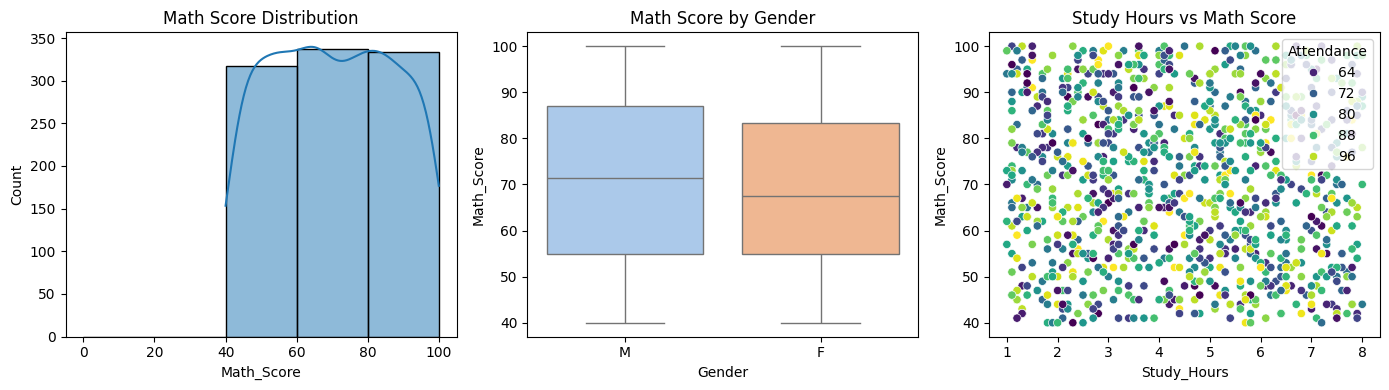

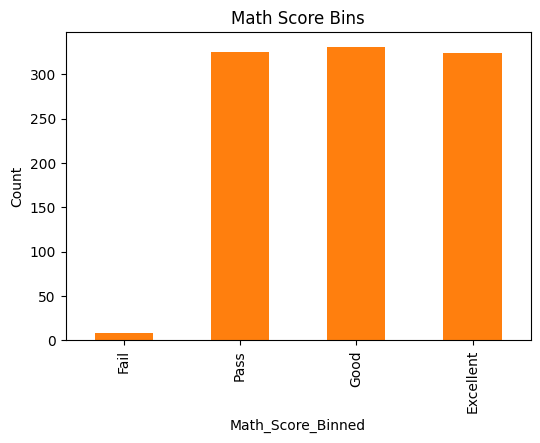

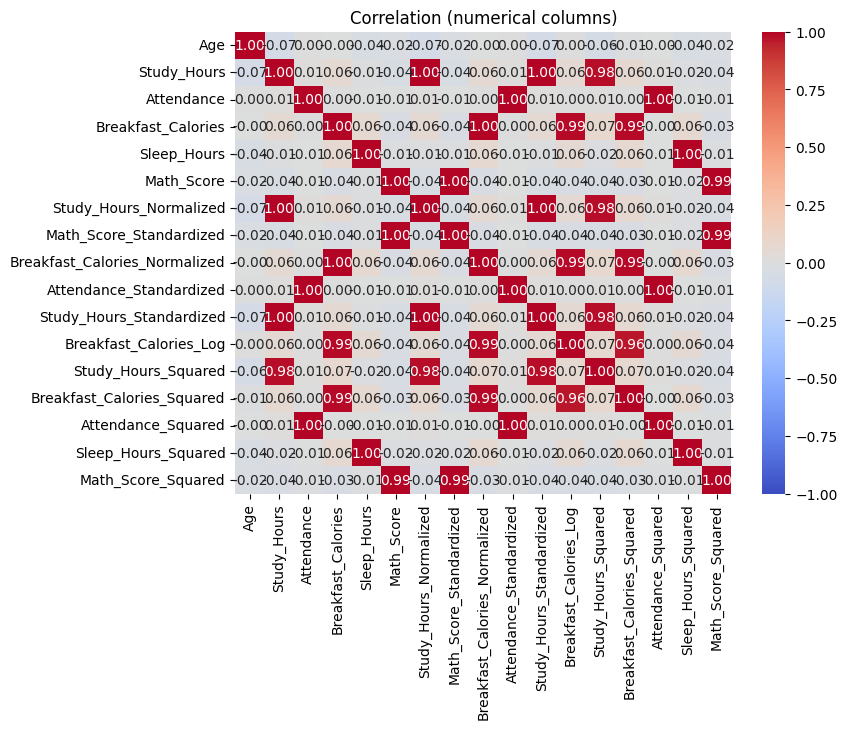

Saved: summary_descriptive_stats.csv, missing_values.csv, group_means_by_gender.csv, group_means_by_math_bin.csv


In [14]:
# Summary tables
desc = df.describe(include='all').T
missing = df.isna().sum()
group_gender = df.groupby('Gender')[numerical_cols].mean()
group_bins = df.groupby('Math_Score_Binned')[numerical_cols].mean()

# Plots: distribution, box, scatter
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
sns.histplot(df['Math_Score'], bins=bins, kde=True, color='C0')
plt.title('Math Score Distribution')

plt.subplot(1,3,2)
sns.boxplot(x='Gender', y='Math_Score', data=df, palette='pastel')
plt.title('Math Score by Gender')

plt.subplot(1,3,3)
sns.scatterplot(x='Study_Hours', y='Math_Score', hue='Attendance', palette='viridis', data=df)
plt.title('Study Hours vs Math Score')
plt.tight_layout()
plt.show()

# Bar plot for binned math scores
counts = df['Math_Score_Binned'].value_counts().reindex(labels, fill_value=0)
plt.figure(figsize=(6,4))
counts.plot(kind='bar', color='C1')
plt.title('Math Score Bins')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numerical columns
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (numerical columns)')
plt.show()

# Save reports (fixed file path strings)
desc.to_csv(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Csv\summary_descriptive_stats.csv")
missing.to_frame('missing_count').to_csv(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Csv\missing_values.csv")
group_gender.to_csv(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Csv\group_means_by_gender.csv", index=False)
group_bins.to_csv(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Csv\group_means_by_math_bin.csv", index=False)

print("Saved: summary_descriptive_stats.csv, missing_values.csv, group_means_by_gender.csv, group_means_by_math_bin.csv")

In [15]:
import os

png_dir = r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Png"
os.makedirs(png_dir, exist_ok=True)

# Study Hours boxplot
fig = plt.figure()
plt.boxplot(df['Study_Hours'])
plt.title('Distribution of Study Hours')
plt.ylabel('Study Hours')
fig.savefig(os.path.join(png_dir, 'study_hours_box.png'), bbox_inches='tight')
plt.close(fig)

# Math Score histogram
fig = plt.figure()
plt.hist(df['Math_Score'], bins=10, edgecolor='black')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Scores')
plt.ylabel('Frequency')
fig.savefig(os.path.join(png_dir, 'math_score_hist.png'), bbox_inches='tight')
plt.close(fig)

# Breakfast Calories boxplot
fig = plt.figure()
plt.boxplot(df['Breakfast_Calories'])
plt.title('Distribution of Breakfast Calories')
plt.ylabel('Breakfast Calories')
fig.savefig(os.path.join(png_dir, 'breakfast_calories_box.png'), bbox_inches='tight')
plt.close(fig)

# Attendance histogram
fig = plt.figure()
plt.hist(df['Attendance'], bins=10, edgecolor='black')
plt.title('Distribution of Attendance')
plt.xlabel('Attendance')
plt.ylabel('Frequency')
fig.savefig(os.path.join(png_dir, 'attendance_hist.png'), bbox_inches='tight')
plt.close(fig)

# Study_Hours vs Math_Score scatter
fig, ax = plt.subplots()
sns.scatterplot(x='Study_Hours', y='Math_Score', data=df, ax=ax)
ax.set_title('Study Hours vs Math Score')
ax.set_xlabel('Study Hours')
ax.set_ylabel('Math Score')
fig.savefig(os.path.join(png_dir, 'study_vs_math.png'), bbox_inches='tight')
plt.close(fig)

# Breakfast_Calories vs Math_Score scatter
fig, ax = plt.subplots()
sns.scatterplot(x='Breakfast_Calories', y='Math_Score', data=df, ax=ax)
ax.set_title('Breakfast Calories vs Math Score')
ax.set_xlabel('Breakfast Calories')
ax.set_ylabel('Math Score')
fig.savefig(os.path.join(png_dir, 'breakfast_vs_math.png'), bbox_inches='tight')
plt.close(fig)

# Summary 3-panel (distribution, box by gender, scatter with attendance hue)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df['Math_Score'], bins=bins, kde=True, color='C0', ax=axes[0])
axes[0].set_title('Math Score Distribution')

sns.boxplot(x='Gender', y='Math_Score', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Math Score by Gender')

sns.scatterplot(x='Study_Hours', y='Math_Score', hue='Attendance', palette='viridis', data=df, ax=axes[2])
axes[2].set_title('Study Hours vs Math Score')

plt.tight_layout()
fig.savefig(os.path.join(png_dir, 'summary_3panel.png'), bbox_inches='tight')
plt.close(fig)

# Bar plot for binned math scores
counts_ordered = counts.reindex(labels, fill_value=0)
fig = plt.figure(figsize=(6,4))
counts_ordered.plot(kind='bar', color='C1')
plt.title('Math Score Bins')
plt.ylabel('Count')
fig.savefig(os.path.join(png_dir, 'math_score_bins_bar.png'), bbox_inches='tight')
plt.close(fig)

# Correlation heatmap for numerical columns
fig = plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (numerical columns)')
fig.savefig(os.path.join(png_dir, 'correlation_heatmap.png'), bbox_inches='tight')
plt.close(fig)

print(f"Saved PNG reports to: {png_dir}")

C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_23516\3629508444.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Math_Score', data=df, palette='pastel', ax=axes[1])


Saved PNG reports to: C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Png


In [18]:
numeric_cols = ['Age', 'Study_Hours', 'Attendance', 'Breakfast_Calories', 'Sleep_Hours', 'Math_Score']

final_df = df.copy()

# Z-score standardized features
std_scaler = StandardScaler()
final_df[[f'Z_{col}' for col in numeric_cols]] = std_scaler.fit_transform(final_df[numeric_cols])

# Min-Max normalized features
minmax_scaler = MinMaxScaler()
final_df[[f'MinMax_{col}' for col in numeric_cols]] = minmax_scaler.fit_transform(final_df[numeric_cols])

# Polynomial feature
final_df['Study_Hours_Squared'] = final_df['Study_Hours'] ** 2

# Binned grade categories
bins = [0, 40, 60, 80, 100]
labels = ['Fail', 'Pass', 'Good', 'Excellent']
final_df['Math_Score_Binned'] = pd.cut(final_df['Math_Score'], bins=bins, labels=labels, include_lowest=True)

final_df.to_excel(final_output_path, index=False)
print(f"Saved final engineered data to: {final_output_path}")

Saved final engineered data to: C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Numerical\Data\final_engineered_students.xlsx
